In [27]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [28]:
batch_size = 32
img_height =250
img_width =250

In [29]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  "eye_image",
  validation_split=0.8,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 138 files belonging to 6 classes.
Using 28 files for training.


In [30]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  "eye_image",
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 138 files belonging to 6 classes.
Using 27 files for validation.


In [31]:
class_names = train_ds.class_names
print(class_names)

['Cataracts', 'Glaucoma', 'Keratoconus', 'Uveitis', 'normal', 'proptosis']


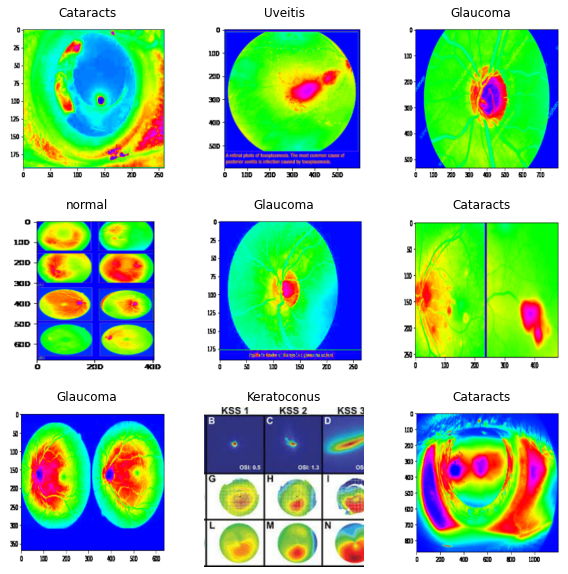

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [33]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(28, 250, 250, 3)
(28,)


In [34]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [35]:
normalization_layer = layers.Rescaling(1./255)

In [36]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [37]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [38]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [39]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_4 (Rescaling)     (None, 250, 250, 3)       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 250, 250, 16)      448       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 125, 125, 16)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 62, 62, 32)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 62, 62, 64)       

In [40]:
epochs=60
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/60
1/1 [==============================] - 2s 2s/step - loss: 1.8117 - accuracy: 0.1071 - val_loss: 7.7907 - val_accuracy: 0.0741
Epoch 2/60
1/1 [==============================] - 1s 898ms/step - loss: 4.6978 - accuracy: 0.2857 - val_loss: 5.9028 - val_accuracy: 0.1852
Epoch 3/60
1/1 [==============================] - 1s 957ms/step - loss: 4.8059 - accuracy: 0.2143 - val_loss: 3.7025 - val_accuracy: 0.1852
Epoch 4/60
1/1 [==============================] - 1s 915ms/step - loss: 3.1855 - accuracy: 0.2143 - val_loss: 2.0028 - val_accuracy: 0.1852
Epoch 5/60
1/1 [==============================] - 1s 945ms/step - loss: 1.7512 - accuracy: 0.2143 - val_loss: 1.8896 - val_accuracy: 0.1481
Epoch 6/60
1/1 [==============================] - 1s 1s/step - loss: 1.5158 - accuracy: 0.2857 - val_loss: 2.1973 - val_accuracy: 0.1111
Epoch 7/60
1/1 [==============================] - 1s 997ms/step - loss: 1.5148 - accuracy: 0.3929 - val_loss: 2.1863 - val_accuracy: 0.0741
Epoch 8/60
1/1 [==========

Epoch 59/60
1/1 [==============================] - 1s 1s/step - loss: 2.1756e-06 - accuracy: 1.0000 - val_loss: 6.9293 - val_accuracy: 0.1481
Epoch 60/60
1/1 [==============================] - 1s 996ms/step - loss: 2.0947e-06 - accuracy: 1.0000 - val_loss: 6.9455 - val_accuracy: 0.1481


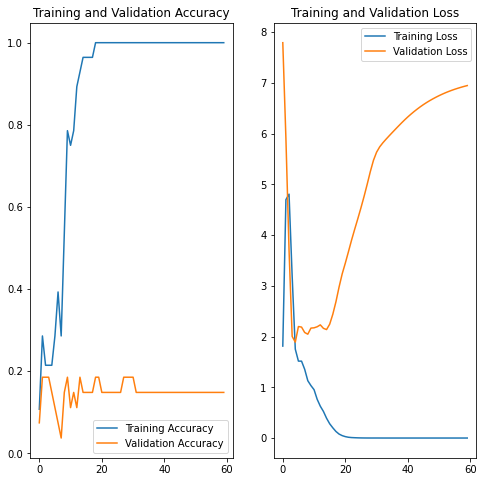

In [41]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [42]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

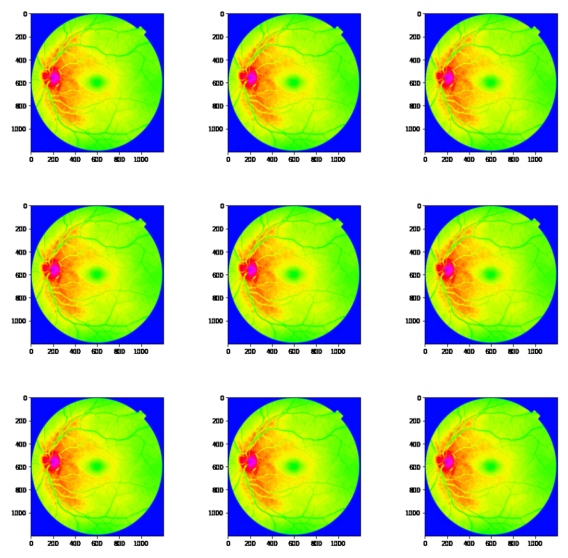

In [43]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [44]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [45]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [46]:
epochs =60
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/60
1/1 [==============================] - 2s 2s/step - loss: 1.8207 - accuracy: 0.0714 - val_loss: 9.7449 - val_accuracy: 0.0741
Epoch 2/60
1/1 [==============================] - 1s 1s/step - loss: 4.5078 - accuracy: 0.2857 - val_loss: 11.3180 - val_accuracy: 0.1852
Epoch 3/60
1/1 [==============================] - 1s 1s/step - loss: 8.5936 - accuracy: 0.2143 - val_loss: 7.3616 - val_accuracy: 0.1852
Epoch 4/60
1/1 [==============================] - 1s 1s/step - loss: 5.7679 - accuracy: 0.2143 - val_loss: 4.0992 - val_accuracy: 0.2222
Epoch 5/60
1/1 [==============================] - 1s 1s/step - loss: 3.1837 - accuracy: 0.2500 - val_loss: 2.5512 - val_accuracy: 0.1111
Epoch 6/60
1/1 [==============================] - 1s 1s/step - loss: 1.9427 - accuracy: 0.1071 - val_loss: 2.1101 - val_accuracy: 0.1111
Epoch 7/60
1/1 [==============================] - 1s 1s/step - loss: 1.6870 - accuracy: 0.3214 - val_loss: 2.1207 - val_accuracy: 0.0741
Epoch 8/60
1/1 [========================

1/1 [==============================] - 1s 1s/step - loss: 0.0323 - accuracy: 1.0000 - val_loss: 3.6008 - val_accuracy: 0.3333


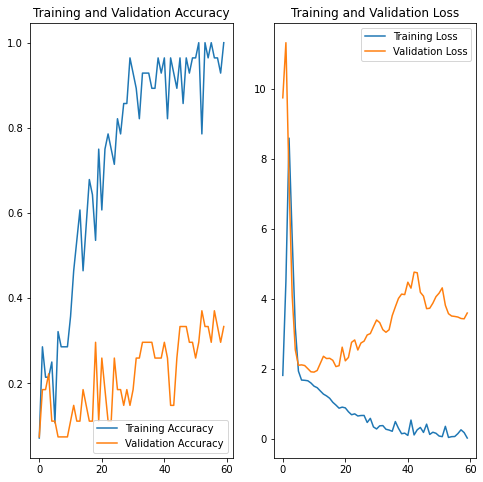

In [47]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Keratoconus
1/1 [==============================] - 0s 167ms/step
predicted label: Cataracts


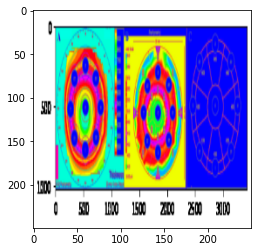

In [53]:
import numpy as np
for images_batch, labels_batch in val_ds.take(1):
    
    first_image = images_batch[1].numpy().astype('uint8')
    first_label = labels_batch[1].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [49]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 26ms/step


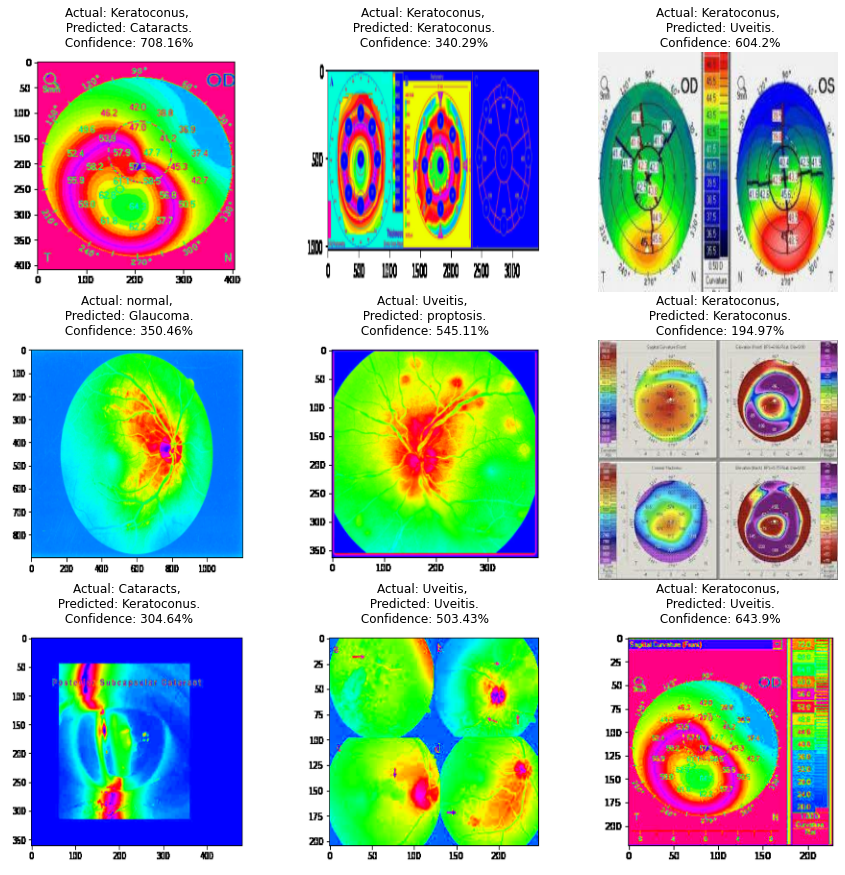

In [50]:
plt.figure(figsize=(15, 15))
for images, labels in val_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [52]:
import os
model_version=max([int(i) for i in os.listdir("../saved_models") + [1]])+1
model.save(f"../models/{model_version}")

INFO:tensorflow:Assets written to: ../models/2\assets


INFO:tensorflow:Assets written to: ../models/2\assets
